# Sequential Bayesian Updating with Probability Smoothing

## Problem: Estimating Website Conversion Probability

Suppose a website receives a continuous stream of visitors, and we want to estimate the underlying probability that a visitor completes a purchase.

Let $\theta$ denote the unknown probability that a visitor converts:

$$
\theta = P(\text{visitor converts})
$$

Each visitor produces one of two possible outcomes:

$$
Y_i =
\begin{cases}
1, & \text{if the visitor converts} \\
0, & \text{if the visitor does not convert}
\end{cases}
$$

A challenge arises when only a small number of observations are available. For example, suppose none of the first five visitors converts. The raw empirical estimate would be

$$
\hat{\theta}_{\text{raw}} = \frac{0}{5} = 0.
$$

This would suggest that the probability of conversion is exactly zero. Such a conclusion is too strong given that only five visitors have been observed.

To obtain more stable estimates, we combine two related ideas:

1.  **Probability smoothing**, where pseudo-counts prevent extreme estimates based on very small samples.
2.  **Sequential Bayesian updating**, where the posterior distribution after one observation becomes the prior distribution for the next observation.

---

## 1. Prior Belief

Before observing the new visitor data, suppose historical information suggests that the conversion probability is relatively low.

We represent this belief using a Beta distribution:

$$
\theta \sim \operatorname{Beta}(2,8).
$$

For a Beta distribution,

$$
\theta \sim \operatorname{Beta}(\alpha,\beta),
$$

the mean is

$$
E[\theta] = \frac{\alpha}{\alpha+\beta}.
$$

Therefore, our initial prior mean is

$$
E[\theta] = \frac{2}{2+8} = 0.20.
$$

Thus, before observing the new data, our expected conversion probability is approximately **20%**.

The parameters of the Beta distribution can also be interpreted as prior pseudo-counts. In this example, $\alpha=2$ provides prior weight toward conversions, while $\beta=8$ provides prior weight toward non-conversions.

Because both parameters are positive, the prior helps prevent the estimated probability from immediately collapsing to exactly 0 or 1 when only a few observations have been collected.

---

## 2. Relationship to Laplace Smoothing

Strict Laplace, or **add-one**, smoothing adds one pseudo-count to each possible binary outcome.

Suppose we have observed $s$ conversions from $n$ visitors.

The raw empirical estimate is

$$
\hat{\theta}_{\text{raw}} = \frac{s}{n}.
$$

Laplace smoothing instead gives

$$
\hat{\theta}_{\text{Laplace}} = \frac{s+1}{n+2}.
$$

The denominator contains $n+2$ because we add one pseudo-conversion and one pseudo-non-conversion.

For example, after observing zero conversions among the first five visitors,

$$
\hat{\theta}_{\text{raw}} = \frac{0}{5} = 0,
$$

whereas Laplace smoothing gives

$$
\hat{\theta}_{\text{Laplace}} = \frac{0+1}{5+2} = \frac{1}{7} \approx 0.143.
$$

The estimate therefore remains above zero despite observing no conversions.

Strict Laplace smoothing has a Bayesian interpretation. It corresponds to the prior

$$
\theta \sim \operatorname{Beta}(1,1).
$$

In this notebook, however, the Bayesian model uses the more informative prior

$$
\theta \sim \operatorname{Beta}(2,8).
$$

Therefore, the **Bayesian posterior** and the **strict Laplace-smoothed estimate** are calculated separately so that their behavior can be compared.

---

## 3. Sequential Observations

Visitors arrive one at a time.

For each visitor,

$$
Y_i=1
$$

represents a conversion, while

$$
Y_i=0
$$

represents a non-conversion.

Each observation is modeled using a Bernoulli distribution:

$$
Y_i \mid \theta
\sim
\operatorname{Bernoulli}(\theta).
$$

Therefore,

$$
P(Y_i=1 \mid \theta)=\theta
$$

and

$$
P(Y_i=0 \mid \theta)=1-\theta.
$$

Instead of waiting until all visitor observations have been collected, we update our belief about $\theta$ every time a new observation arrives.

---

## 4. Sequential Bayesian Updating

Bayes' rule states that the posterior distribution is proportional to the likelihood multiplied by the prior:

$$
p(\theta \mid D)
\propto
p(D \mid \theta)p(\theta).
$$

Suppose the first visitor produces observation $Y_1$. The first posterior is

$$
p(\theta \mid Y_1)
\propto
p(Y_1 \mid \theta)p(\theta).
$$

When the second observation $Y_2$ arrives, the previous posterior becomes the new prior:

$$
p(\theta \mid Y_1,Y_2)
\propto
p(Y_2 \mid \theta)
p(\theta \mid Y_1).
$$

More generally, define

$$
p_t(\theta) = p(\theta \mid Y_1,\ldots,Y_t).
$$

The recursive Bayesian update is then

$$
p_t(\theta)
\propto
p(Y_t \mid \theta)p_{t-1}(\theta).
$$

Therefore, the updating process is

**Initial Prior → Posterior 1 → Posterior 2 → ... → Final Posterior**

The important idea is that the posterior after processing observation $t-1$ becomes the prior before processing observation $t$.

This allows information from all previous observations to be carried forward without recomputing the posterior from scratch.

---

## 5. Numerical Bayesian Update

For each new observation, we first calculate its likelihood.

If the visitor converts, $Y_t=1$, then

$$
p(Y_t \mid \theta)=\theta.
$$

If the visitor does not convert, $Y_t=0$, then

$$
p(Y_t \mid \theta)=1-\theta.
$$

The unnormalized posterior is

$$
\tilde{p}_t(\theta) = p_{t-1}(\theta)p(Y_t \mid \theta).
$$

Because this function does not necessarily integrate to one, we calculate the normalization constant

$$
Z_t = \int_0^1 \tilde{p}_t(\theta) \,d\theta.
$$

The normalized posterior is then

$$
p_t(\theta) = \frac{\tilde{p}_t(\theta)}{Z_t}.
$$

The notebook performs this calculation numerically after every new visitor observation.

---

## 6. Sequential Updating Loop

We begin with the initial distribution

$$
p_0(\theta) = \operatorname{Beta}(2,8).
$$

For every new observation $Y_t$, we calculate

$$
p_t(\theta) = \operatorname{Update} \left( p_{t-1}(\theta),Y_t \right).
$$

The resulting posterior is stored and then passed back into the update function as the prior for the next observation.

Conceptually,

$$
p_0(\theta)
\xrightarrow{Y_1}
p_1(\theta)
\xrightarrow{Y_2}
p_2(\theta)
\xrightarrow{Y_3}
\cdots
\xrightarrow{Y_n}
p_n(\theta).
$$

This is the central sequential Bayesian component of the notebook.

---

## 7. Sequential Laplace Smoothing

Alongside the full Bayesian posterior distributions, we track the empirical conversion probability after every visitor.

After $t$ observations, let

$$
s_t = \sum_{i=1}^{t}Y_i
$$

be the cumulative number of conversions.

The raw estimate is

$$
\hat{\theta}_{t,\text{raw}} = \frac{s_t}{t}.
$$

The corresponding Laplace-smoothed estimate is

$$
\hat{\theta}_{t,\text{Laplace}} = \frac{s_t+1}{t+2}.
$$

These two quantities can be plotted sequentially.

The comparison demonstrates why smoothing is particularly useful early in the data stream. If the first several observations are all non-conversions, the raw estimate becomes exactly zero, whereas the Laplace-smoothed estimate remains positive.

As the number of observations increases, the relative influence of the pseudo-counts decreases and the smoothed estimate becomes increasingly dominated by the observed data.

---

## 8. Final Bayesian Posterior

The Beta distribution is conjugate to the Bernoulli likelihood.

Therefore, if

$$
\theta \sim \operatorname{Beta}(\alpha,\beta)
$$

and the observed data contain $s$ conversions and $f$ non-conversions, then

$$
\theta \mid D
\sim
\operatorname{Beta}(\alpha+s,\beta+f).
$$

In this notebook,

$$
\alpha=2,
\qquad
\beta=8.
$$

The observed sequence contains

$$
s=4
$$

conversions and

$$
f=16
$$

non-conversions.

Therefore,

$$
\alpha_{\text{posterior}} = 2+4 = 6
$$

and

$$
\beta_{\text{posterior}} = 8+16 = 24.
$$

The final posterior distribution is therefore

$$
\boxed{
\theta \mid D
\sim
\operatorname{Beta}(6,24)
}
$$

with posterior mean

$$
E[\theta \mid D] = \frac{6}{6+24} = 0.20.
$$

---

## 9. Initial Prior vs. Final Posterior

The notebook plots the initial prior distribution

$$
\operatorname{Beta}(2,8)
$$

and the final posterior distribution

$$
\operatorname{Beta}(6,24)
$$

on the same graph.

Although both distributions happen to have a mean of 0.20 in this example, they do **not** represent the same state of knowledge.

Initially,

$$
\theta \sim \operatorname{Beta}(2,8)
$$

represents relatively uncertain prior knowledge.

After observing 20 additional visitors,

$$
\theta \mid D
\sim
\operatorname{Beta}(6,24)
$$

is more concentrated around 0.20.

Thus, the new observations have increased our **certainty** about the conversion probability even though the estimated mean has not changed.

This demonstrates an important property of Bayesian inference:

> New evidence can reduce posterior uncertainty even when the posterior mean remains unchanged.

---

## 10. Comparing Raw, Laplace-Smoothed, and Bayesian Estimates

For the complete dataset, the raw observed conversion rate is

$$
\hat{\theta}_{\text{raw}} = \frac{4}{20} = 0.20.
$$

Strict Laplace smoothing gives

$$
\hat{\theta}_{\text{Laplace}} = \frac{4+1}{20+2} = \frac{5}{22} \approx 0.227.
$$

The Bayesian posterior mean under the informative $\operatorname{Beta}(2,8)$ prior is

$$
E[\theta \mid D] = \frac{2+4}{2+8+20} = \frac{6}{30} = 0.20.
$$

Therefore,

$$
\hat{\theta}_{\text{raw}}=0.20,
$$

$$
\hat{\theta}_{\text{Laplace}}\approx0.227,
$$

and

$$
E[\theta \mid D]=0.20.
$$

The difference arises because strict Laplace smoothing corresponds to a

$$
\operatorname{Beta}(1,1)
$$

prior, whereas the Bayesian model in this notebook uses the informative prior

$$
\operatorname{Beta}(2,8).
$$

---

## 11. Methodology Summary

The sequential Bayesian methodology can be summarized as:

**Prior belief → Observe new outcome → Calculate likelihood → Apply Bayes' rule → Normalize posterior → Use posterior as the next prior → Repeat**

At each step, the Bayesian update is

$$
p_t(\theta)
\propto
p(Y_t \mid \theta)p_{t-1}(\theta).
$$

At the same time, the Laplace-smoothed empirical estimate is calculated as

$$
\hat{\theta}_{t,\text{Laplace}} = \frac{s_t+1}{t+2}.
$$

The notebook therefore demonstrates three related concepts:

*   **Sequential Bayesian inference:** continuously updates the full probability distribution as new observations arrive.
*   **Bayesian pseudo-count smoothing:** the Beta prior stabilizes inference when only limited data are available.
*   **Laplace smoothing:** add-one smoothing prevents empirical probability estimates from becoming exactly 0 or 1 based on a small number of observations.

Finally, comparing the initial $\operatorname{Beta}(2,8)$ distribution with the final $\operatorname{Beta}(6,24)$ distribution illustrates that Bayesian learning updates not only the expected value of an unknown probability but also our **uncertainty about that probability**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import beta
import scipy.integrate as integrate

In [13]:
# ============================================================
# Bayesian prior
# ============================================================

# theta = probability that a website visitor converts

a, b = 2, 8

rv = beta(a, b)

# Prior probability density
prior = lambda theta: rv.pdf(theta)

# Possible values of theta
x = np.linspace(0, 1, 1000)


#Compute High-Density-Interval(Credible Interval)
def compute_hdi(x, pdf, credible_mass=0.95):

    pdf = pdf / np.sum(pdf)

    sorted_idx = np.argsort(pdf)[::-1]

    sorted_pdf = pdf[sorted_idx]
    sorted_x = x[sorted_idx]

    cumulative = np.cumsum(sorted_pdf)

    cutoff_idx = np.searchsorted(
        cumulative,
        credible_mass
    )

    hdi_x = sorted_x[:cutoff_idx + 1]

    return np.min(hdi_x), np.max(hdi_x)

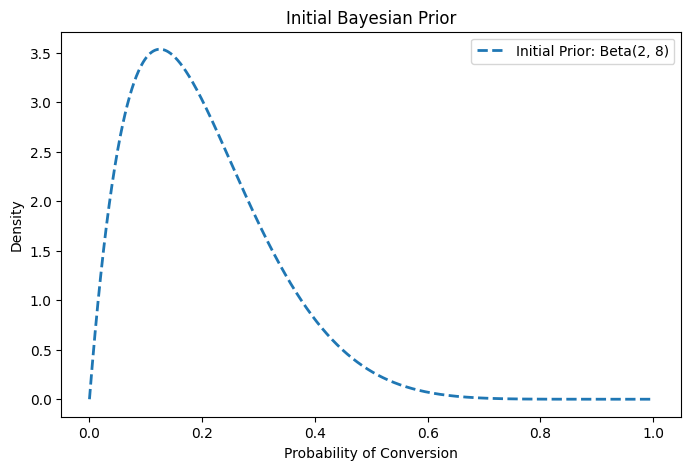

In [14]:
# ============================================================
# Initial prior distribution
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    prior(x),
    linestyle="dashed",
    linewidth=2,
    label="Initial Prior: Beta(2, 8)"
)

plt.xlabel("Probability of Conversion")
plt.ylabel("Density")
plt.title("Initial Bayesian Prior")

plt.legend()
plt.show()

In [15]:
# ============================================================
# Bayesian update function
# ============================================================

def update_prob(prior, observation):
    """
    Perform one sequential Bayesian update.

    observation = 1 -> conversion
    observation = 0 -> no conversion
    """

    # Bernoulli likelihood
    likelihood = lambda theta: (
        theta if observation == 1 else (1 - theta)
    )

    # Unnormalized posterior
    posterior_unnorm = lambda theta: (
        prior(theta) * likelihood(theta)
    )

    # Normalizing constant
    evidence = integrate.quad(
        posterior_unnorm,
        0,
        1
    )[0]

    # Normalized posterior
    posterior = lambda theta: (
        posterior_unnorm(theta) / evidence
    )

    return posterior

In [16]:
# ============================================================
# Sequential observations
# ============================================================

# 1 = conversion
# 0 = non-conversion
#
# 20 visitors:
# 4 conversions
# 16 non-conversions

observations = [
    0, 0, 0, 0, 0,
    0, 0, 0, 0, 0,
    0, 0, 0, 0, 0,
    0, 1, 1, 1, 1
]

print("Number of observations:", len(observations))
print("Conversions:", sum(observations))
print("Non-conversions:", len(observations) - sum(observations))

Number of observations: 20
Conversions: 4
Non-conversions: 16


In [17]:
# ============================================================
# Sequential Bayesian updating
# ============================================================

posteriors = [prior]

current_prob = prior

for observation in observations:

    # Update using the new observation
    current_prob = update_prob(
        current_prob,
        observation
    )

    # Save the updated posterior
    posteriors.append(current_prob)

In [18]:
# ============================================================
# Laplace smoothing
# ============================================================

raw_rates = []
laplace_rates = []

successes_so_far = 0

for i, observation in enumerate(observations, start=1):

    # Update number of conversions
    successes_so_far += observation

    # Raw empirical probability
    raw_rate = successes_so_far / i

    # Laplace smoothing:
    # add 1 pseudo-success and 1 pseudo-failure
    laplace_rate = (
        successes_so_far + 1
    ) / (
        i + 2
    )

    raw_rates.append(raw_rate)
    laplace_rates.append(laplace_rate)

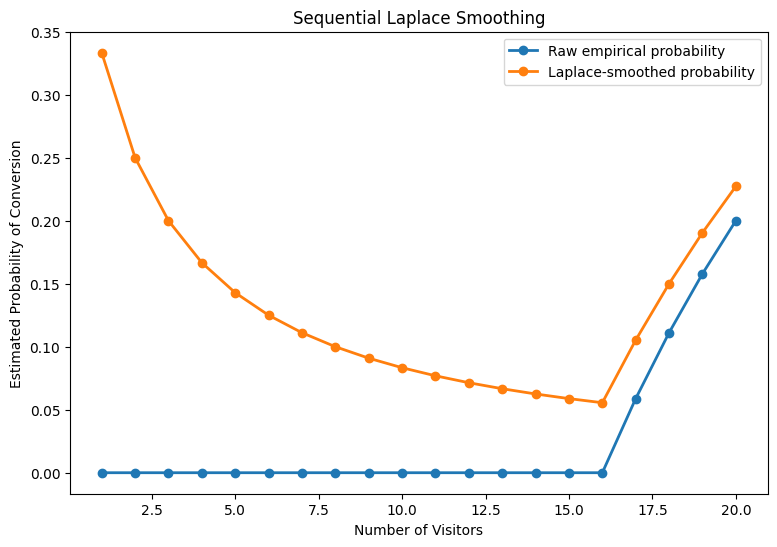

In [19]:
# ============================================================
# Raw vs Laplace-smoothed estimates
# ============================================================

steps = np.arange(
    1,
    len(observations) + 1
)

plt.figure(figsize=(9, 6))

plt.plot(
    steps,
    raw_rates,
    marker="o",
    linewidth=2,
    label="Raw empirical probability"
)

plt.plot(
    steps,
    laplace_rates,
    marker="o",
    linewidth=2,
    label="Laplace-smoothed probability"
)

plt.xlabel("Number of Visitors")
plt.ylabel("Estimated Probability of Conversion")
plt.title("Sequential Laplace Smoothing")

plt.legend()
plt.show()


Final Posterior
-----------------------
alpha = 6
beta  = 24
mean  = 0.200
95% HDI = [0.070, 0.342]


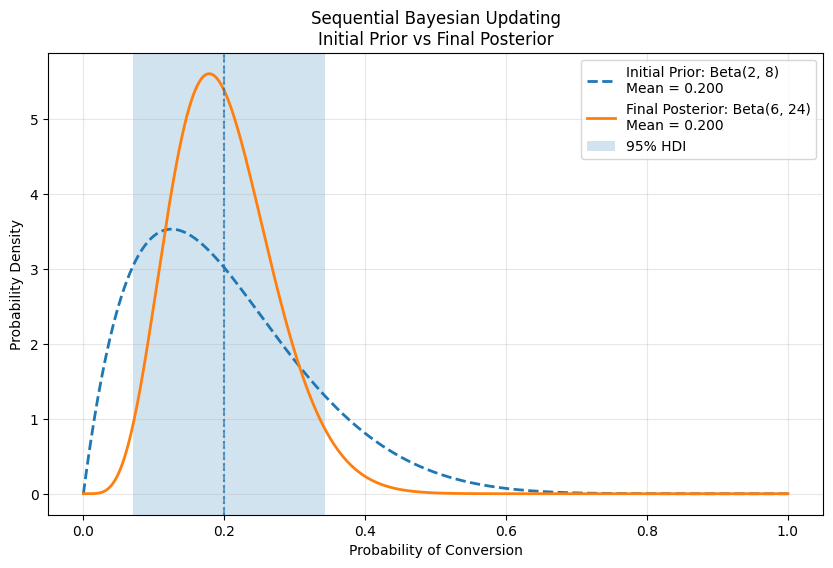


Initial Prior
-----------------------
alpha = 2
beta  = 8
mean  = 0.200

Observed Data
-----------------------
conversions     = 4
non-conversions = 16

Final Posterior
-----------------------
alpha = 6
beta  = 24
mean  = 0.200
95% HDI = [0.070, 0.342]


In [20]:
# ============================================================
# Plot initial and final probability distributions
# along with their parameters
# ============================================================

# Count observed outcomes
successes = np.sum(observations)
failures = len(observations) - successes


# ------------------------------------------------------------
# Initial prior parameters
# ------------------------------------------------------------

a_prior = a
b_prior = b

prior_mean = a_prior / (a_prior + b_prior)


# ------------------------------------------------------------
# Final posterior parameters
# ------------------------------------------------------------

a_post = a_prior + successes
b_post = b_prior + failures

posterior_mean = a_post / (a_post + b_post)


# ------------------------------------------------------------
# Initial and final distributions from sequential updating
# ------------------------------------------------------------

initial_prob = posteriors[0]
final_prob = posteriors[-1]

x = np.linspace(0, 1, 1000)

initial_density = np.array([
    initial_prob(theta) for theta in x
])

final_density = np.array([
    final_prob(theta) for theta in x
])


# ------------------------------------------------------------
# Final posterior HDI
# ------------------------------------------------------------

credible_mass = 0.95

hdi_lower, hdi_upper = compute_hdi(
    x,
    final_density,
    credible_mass=credible_mass
)


# ------------------------------------------------------------
# Display final posterior
# ------------------------------------------------------------

print("\nFinal Posterior")
print("-----------------------")
print(f"alpha = {a_post}")
print(f"beta  = {b_post}")
print(f"mean  = {posterior_mean:.3f}")
print(
    f"{credible_mass * 100:.0f}% HDI = "
    f"[{hdi_lower:.3f}, {hdi_upper:.3f}]"
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

# Initial prior
plt.plot(
    x,
    initial_density,
    linestyle="dashed",
    linewidth=2,
    label=(
        f"Initial Prior: Beta({a_prior}, {b_prior})\n"
        f"Mean = {prior_mean:.3f}"
    )
)

# Final posterior
plt.plot(
    x,
    final_density,
    linewidth=2,
    label=(
        f"Final Posterior: Beta({a_post}, {b_post})\n"
        f"Mean = {posterior_mean:.3f}"
    )
)


# ------------------------------------------------------------
# Add vertical lines at the means
# ------------------------------------------------------------

plt.axvline(
    prior_mean,
    linestyle="dashed",
    alpha=0.6
)

plt.axvline(
    posterior_mean,
    linestyle="dotted",
    alpha=0.6
)


# ------------------------------------------------------------
# Add posterior HDI
# ------------------------------------------------------------

plt.axvspan(
    hdi_lower,
    hdi_upper,
    alpha=0.2,
    label=f"{credible_mass * 100:.0f}% HDI"
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel("Probability of Conversion")
plt.ylabel("Probability Density")

plt.title(
    "Sequential Bayesian Updating\n"
    "Initial Prior vs Final Posterior"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ------------------------------------------------------------
# Display parameters
# ------------------------------------------------------------

print("\nInitial Prior")
print("-----------------------")
print(f"alpha = {a_prior}")
print(f"beta  = {b_prior}")
print(f"mean  = {prior_mean:.3f}")


print("\nObserved Data")
print("-----------------------")
print(f"conversions     = {successes}")
print(f"non-conversions = {failures}")


print("\nFinal Posterior")
print("-----------------------")
print(f"alpha = {a_post}")
print(f"beta  = {b_post}")
print(f"mean  = {posterior_mean:.3f}")
print(
    f"{credible_mass * 100:.0f}% HDI = "
    f"[{hdi_lower:.3f}, {hdi_upper:.3f}]"
)